# 01 — Yelp Polarity data analysis and preprocessing

**Viraat Chaudhary · DATA 266 Lab 1 · Team 15 · Task 2**

**Preprocessing revision 2: normalize literal escaped whitespace.**

Run **Runtime → Run all** in Colab. This notebook reuses the dataset and raw audit
from your starter run `20261001T203954337938Z`. It writes corrected artifacts into
a new run `20261001T203954337938Z_preprocessing_v2`, preserving the previous run.
The vocabulary and development arrays must be rebuilt because the tokenizer has
changed. Later reruns reuse these corrected artifacts. No dataset download is repeated.

It produces the training/validation membership, training-only vocabulary,
encoded arrays, plots, preprocessing helper, integrity records, evaluation
definitions, and verified Drive backups. **It does not train models.** The
official test reviews and labels are left unopened until all three models have
been selected using validation and frozen for notebook 05.

This is notebook **1 of 7**. Save your executed copy as
`Viraat_01_data_analysis_preprocessing.ipynb` in your own `notebooks/` folder.
Notebooks 02–04 will train your three separately chosen designs; 05 evaluates,
06 supports your manual error review, and 07 demonstrates the evaluator.

**Attribution:** assistant assistance covers data-handling implementation and
checks. Anshika's uploaded notebooks were used only to identify the shared split
algorithm and metric definitions. Her model code is not included or modified.
Your architecture decisions, justifications, findings and manual error analysis
must be written from your own understanding, as required by the course brief.

## 1. Packages and run settings

Keep Colab's PyTorch/CUDA installation. Only missing packages are installed;
actual versions are recorded. Defaults keep the agreed 10% stratified validation
split, 50,000-token vocabulary limit and 256-token sequence cap. Minimum token
frequency is 2; three reserved tokens count toward the vocabulary limit.

The raw-source run ID points to your existing Drive backup. The new processing
run ID protects the old logs and arrays. Keep both IDs unchanged.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path
required = {'datasets': 'datasets==4.8.5', 'numpy': 'numpy',
            'matplotlib': 'matplotlib', 'tqdm': 'tqdm',
            'sklearn': 'scikit-learn==1.6.1', 'nltk': 'nltk==3.9.1'}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import datetime
import hashlib
import importlib.metadata as package_metadata
import json
import platform
import shutil
import time
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import nltk
import torch
from datasets import load_from_disk
from IPython.display import display, Image

RAW_RUN_ID = '20261001T203954337938Z'
RUN_ID = RAW_RUN_ID + '_preprocessing_v2'
MEMBER_NAME = 'Viraat_Chaudhary'
DATASET_ID = 'fancyzhx/yelp_polarity'
DATASET_CONFIG = 'plain_text'
DATASET_REVISION = 'bbf1c97a1f0cf005e5aded43839fd814654a1557'
DATASET_DRIVE_URL = 'https://drive.google.com/drive/folders/1wzaSwbXnBjHUu1dOBT6sX-9PF2jeoovB'
SPLIT_SEED, VALIDATION_FRACTION = 2662501, 0.10
MAX_VOCABULARY, MIN_FREQUENCY, SEQUENCE_LENGTH = 50000, 2, 256
STARTED = time.perf_counter()
print('Run:', RUN_ID, '| member:', MEMBER_NAME)


Run: 20261001T203954337938Z_preprocessing_v2 | member: Viraat_Chaudhary


## 2. Restore your existing workspace and raw data

Authorize the Colab Drive mount if prompted. The saved raw ZIP is checked against
your recorded SHA-256 before extraction when restoration is necessary. Existing
local data are reused. Raw logs are preserved; new events append to a new log.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
WORKSPACE = Path('/content') / f'task2_stage1_{RUN_ID}'
RAW_WORKSPACE = Path('/content') / f'task2_stage1_{RAW_RUN_ID}'
MEMBER_ROOT = WORKSPACE / 'task2_sentiment' / MEMBER_NAME
DATA_ROOT = RAW_WORKSPACE / 'task2_sentiment/data/yelp_polarity'
PROCESSED_ROOT = WORKSPACE / 'task2_sentiment/data/processed' / MEMBER_NAME
DRIVE_MEMBER_ROOT = Path('/content/drive/MyDrive/DATA266_Lab1_Task2') / MEMBER_NAME
RAW_DRIVE_RUN_ROOT = DRIVE_MEMBER_ROOT / RAW_RUN_ID
DRIVE_RUN_ROOT = DRIVE_MEMBER_ROOT / RUN_ID
if not RAW_DRIVE_RUN_ROOT.is_dir():
    raise FileNotFoundError('The raw starter backup was not found. Check the mounted Drive account and RAW_RUN_ID.')
DRIVE_RUN_ROOT.mkdir(parents=True, exist_ok=True)

backup_evidence = DRIVE_RUN_ROOT / 'preprocessing_evidence'
if not (backup_evidence / 'outputs/metrics/preprocessing_completion.json').is_file():
    backup_evidence = RAW_DRIVE_RUN_ROOT / 'stage1_evidence'
if not (MEMBER_ROOT / 'outputs/metrics/dataset_backup_manifest.json').is_file():
    if not backup_evidence.is_dir():
        raise FileNotFoundError('Starter evidence is missing from the Drive backup.')
    shutil.copytree(backup_evidence, MEMBER_ROOT, dirs_exist_ok=True)
for relative in ('src', 'configs', 'notebooks', 'logs', 'outputs/metrics', 'outputs/plots', 'checkpoints'):
    (MEMBER_ROOT / relative).mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

backup_path = MEMBER_ROOT / 'outputs/metrics/dataset_backup_manifest.json'
backup_record = json.loads(backup_path.read_text())
raw_zip = RAW_DRIVE_RUN_ROOT / backup_record['zip_filename']
if not (DATA_ROOT / 'dataset_dict.json').is_file():
    if sha256_file(raw_zip) != backup_record['sha256']:
        raise RuntimeError('The saved raw dataset ZIP hash does not match its manifest.')
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(raw_zip) as archive:
        base = DATA_ROOT.parent.resolve()
        for item in archive.infolist():
            if not (base / item.filename).resolve().is_relative_to(base):
                raise RuntimeError('Unexpected archive path.')
        archive.extractall(base)
    print('Restored raw dataset from the verified ZIP.')
else:
    print('Reusing the existing local raw dataset.')

# A completed preprocessing run can also restore its arrays in a fresh runtime.
processed_backup_file = MEMBER_ROOT / 'outputs/metrics/processed_dataset_backup.json'
if processed_backup_file.exists() and not (PROCESSED_ROOT / 'train_encoding_manifest.json').exists():
    processed_record = json.loads(processed_backup_file.read_text())
    saved_processed_zip = DRIVE_RUN_ROOT / processed_record['zip_filename']
    if sha256_file(saved_processed_zip) != processed_record['sha256']:
        raise RuntimeError('The processed-dataset ZIP hash does not match its manifest.')
    with zipfile.ZipFile(saved_processed_zip) as archive:
        base = PROCESSED_ROOT.parent.parent.resolve()
        base.mkdir(parents=True, exist_ok=True)
        for item in archive.infolist():
            if not (base / item.filename).resolve().is_relative_to(base):
                raise RuntimeError('Unexpected processed archive path.')
        archive.extractall(base)
    print('Restored the completed processed arrays; tokenization will be reused.')

source_manifest = json.loads((DATA_ROOT / 'source_manifest.json').read_text())
assert source_manifest['dataset_id'] == DATASET_ID
assert source_manifest['revision'] == DATASET_REVISION
raw = load_from_disk(str(DATA_ROOT))
assert set(raw) == {'train', 'test'}
assert len(raw['train']) == 560000 and len(raw['test']) == 38000
assert set(raw['train'].column_names) == {'text', 'label'}
assert list(raw['train'].features['label'].names) == ['1', '2']

stamp = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RAW_LOG = MEMBER_ROOT / 'logs' / f'preprocessing_{stamp}.jsonl'
def log_event(event, **fields):
    with RAW_LOG.open('a', encoding='utf-8') as handle:
        handle.write(json.dumps({'time_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
                                 'event': event, **fields}, ensure_ascii=False) + '\n')

if not torch.cuda.is_available() or 'A100' not in torch.cuda.get_device_name(0):
    raise RuntimeError('Select your A100 runtime, then rerun. No data were removed.')
cpu = platform.processor()
if Path('/proc/cpuinfo').exists():
    cpu = next((line.split(':', 1)[1].strip() for line in Path('/proc/cpuinfo').read_text().splitlines()
                if line.startswith('model name')), cpu)
environment = {'captured_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
               'cpu_model': cpu, 'gpu': torch.cuda.get_device_name(0),
               'gpu_memory_gib': torch.cuda.get_device_properties(0).total_memory / 1024**3,
               'python': platform.python_version(), 'cuda': torch.version.cuda,
               'cudnn': torch.backends.cudnn.version(),
               'packages': {name: package_metadata.version(name) for name in
                            ('torch', 'datasets', 'numpy', 'nltk', 'scikit-learn', 'matplotlib', 'tqdm')}}
(MEMBER_ROOT / 'environment_preprocessing.json').write_text(json.dumps(environment, indent=2) + '\n')
log_event('preprocessing_started', run_id=RUN_ID, environment=environment,
          official_test_inspected=False)
print('GPU:', environment['gpu'], '| raw splits:', len(raw['train']), len(raw['test']))


Mounted at /content/drive
Restored raw dataset from the verified ZIP.
GPU: NVIDIA A100-SXM4-40GB | raw splits: 560000 38000


## 3. Display the completed raw audit

These are your saved results, not a second audit. Labels `0` and `1` mean
negative and positive. Raw lengths here use whitespace-separated words.
The earlier audit found no malformed training rows. Unexpected malformed rows
in the pinned data will halt preprocessing with their source index recorded,
rather than silently changing the shared split. Token-empty reviews remain
valid rows and later receive `<empty>`.

{
  "official_train_count": 560000,
  "official_test_count": 38000,
  "class_counts_valid_training": {
    "0": 280000,
    "1": 280000
  },
  "invalid_training_row_count": 0,
  "raw_word_lengths": {
    "count": 560000,
    "min": 1,
    "max": 1052,
    "mean": 133.0288732142857,
    "percentiles": {
      "25": 51.0,
      "50": 97.0,
      "75": 174.0,
      "90": 282.0,
      "95": 372.0,
      "99": 608.0
    }
  },
  "raw_character_lengths": {
    "count": 560000,
    "min": 1,
    "max": 5273,
    "mean": 726.4979232142857,
    "percentiles": {
      "25": 279.0,
      "50": 528.0,
      "75": 947.0,
      "90": 1537.0,
      "95": 2032.0,
      "99": 3333.0
    }
  }
}


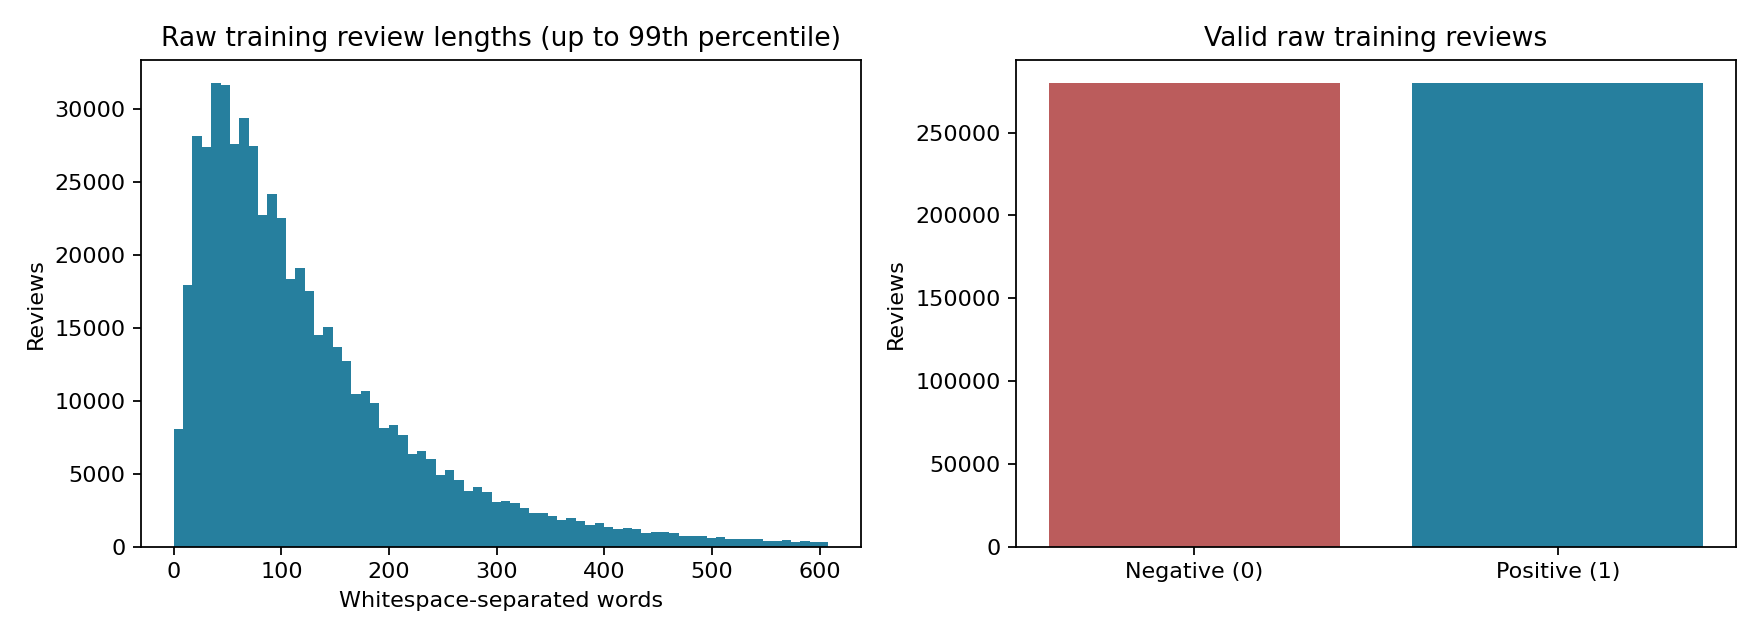

In [3]:
audit = json.loads((MEMBER_ROOT / 'outputs/metrics/raw_dataset_audit.json').read_text())
assert audit['dataset_revision'] == DATASET_REVISION
assert audit['audited_population'] == 'official_train_only'
assert audit['official_train_count'] == 560000
invalid = json.loads((MEMBER_ROOT / 'outputs/metrics/invalid_training_rows.json').read_text())
if audit['invalid_training_row_count'] or invalid:
    raise RuntimeError('Review the recorded malformed rows before freezing membership.')
print(json.dumps({key: audit[key] for key in
      ('official_train_count', 'official_test_count', 'class_counts_valid_training',
       'invalid_training_row_count', 'raw_word_lengths', 'raw_character_lengths')}, indent=2))
plot = MEMBER_ROOT / 'outputs/plots/raw_training_distribution.png'
if plot.is_file():
    display(Image(filename=str(plot)))


## 4. Preserve and check your preprocessing

This revision adds normalization of literal escaped newlines, carriage returns
and tabs before tokenization. Otherwise it retains Cell 6 behavior: HTML entity decoding,
Unicode NFKC, lowercase, HTML removal, expanded negative contractions, Unicode
alphabetic tokens, NLTK English stopwords with nine negations preserved, and
Porter stemming. Punctuation, digits and special characters are excluded.

The exact effective stopword list is saved and reused. Your tokenizer differs
from Anshika's tokenizer; it is not copied from her notebook. The helper below
is generated into **your own** `src/yelp_data.py` for later notebooks.

In [4]:
HELPER_SOURCE = '"""Viraat\'s Yelp preprocessing utilities. No model implementations.\n\nAssistant-assisted implementation, starting from Viraat\'s checked Cell 6.\nRevision 2 normalizes Yelp\'s literal escaped whitespace before tokenization.\nTeam notebooks were consulted only for the split and metric conventions.\nAPI references: nltk.org/api/nltk.stem.porter.html;\nscikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html;\nnumpy.org/doc/stable/reference/generated/numpy.lib.format.open_memmap.html.\n"""\nimport hashlib\nimport html\nimport json\nimport re\nimport unicodedata\nfrom collections import Counter\nfrom functools import lru_cache\nfrom pathlib import Path\nimport numpy as np\nfrom nltk.stem import PorterStemmer\nfrom sklearn.model_selection import train_test_split\nfrom tqdm.auto import tqdm\n\nNEGATIONS = frozenset({\'no\', \'not\', \'nor\', \'never\', \'neither\',\n                       \'without\', \'hardly\', \'barely\', \'scarcely\'})\nRESERVED = {\'<pad>\': 0, \'<unk>\': 1, \'<empty>\': 2}\nTOKEN_PATTERN = r\'[^\\W\\d_]+\'\n\n\ndef sha256_file(path):\n    digest = hashlib.sha256()\n    with Path(path).open(\'rb\') as handle:\n        for block in iter(lambda: handle.read(8 * 1024 * 1024), b\'\'):\n            digest.update(block)\n    return digest.hexdigest()\n\n\ndef fingerprint(payload):\n    encoded = json.dumps(payload, sort_keys=True, ensure_ascii=False,\n                         separators=(\',\', \':\')).encode(\'utf-8\')\n    return hashlib.sha256(encoded).hexdigest()\n\n\ndef array_digest(values):\n    return hashlib.sha256(np.ascontiguousarray(values).tobytes()).hexdigest()\n\n\ndef write_json(path, payload):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = path.with_name(path.name + \'.part\')\n    temporary.write_text(json.dumps(payload, indent=2, ensure_ascii=False) + \'\\n\',\n                         encoding=\'utf-8\')\n    temporary.replace(path)\n\n\ndef build_preprocessor(stop_words):\n    stop_words = frozenset(stop_words) - NEGATIONS\n    stemmer = PorterStemmer(mode=PorterStemmer.NLTK_EXTENSIONS)\n    words = re.compile(TOKEN_PATTERN, re.UNICODE)\n    special = {\'cannot\': \'can not\', "can\'t": \'can not\', "won\'t": \'will not\',\n               "shan\'t": \'shall not\', "ain\'t": \'is not\'}\n    special_pattern = re.compile(r\'\\b(?:\' + \'|\'.join(re.escape(w) for w in special) + r\')\\b\')\n    contraction = re.compile(r"\\b([^\\W\\d_]+)n\'t\\b", re.UNICODE)\n\n    @lru_cache(maxsize=100_000)\n    def stem(token):\n        return token if token in NEGATIONS else stemmer.stem(token)\n\n    def tokenize(review):\n        if not isinstance(review, str):\n            raise TypeError(\'Review must be a string; quarantine invalid raw rows separately.\')\n        text = unicodedata.normalize(\'NFKC\', html.unescape(review)).lower()\n        text = text.replace(\'\\u2019\', "\'").replace(\'\\u2018\', "\'")\n        # Yelp stores some line breaks as two literal characters: backslash + n.\n        # Handle only whitespace escapes; do not use unicode_escape on Unicode text.\n        text = re.sub(r\'\\\\[nrt]\', \' \', text)\n        text = re.sub(r\'<!--.*?-->\', \' \', text, flags=re.DOTALL)\n        text = re.sub(r\'</?[a-z][^>]*>\', \' \', text)\n        text = special_pattern.sub(lambda match: special[match.group(0)], text)\n        text = contraction.sub(lambda match: match.group(1) + \' not\', text)\n        return [stem(token) for token in words.findall(text) if token not in stop_words]\n\n    return tokenize\n\n\ndef make_membership(labels, validation_fraction, seed):\n    labels = np.asarray(labels)\n    if labels.ndim != 1 or not np.isin(labels, [0, 1]).all():\n        raise ValueError(\'Training labels must be a one-dimensional binary array.\')\n    indices = np.arange(len(labels), dtype=np.int32)\n    training, validation = train_test_split(\n        indices, test_size=validation_fraction, random_state=seed,\n        shuffle=True, stratify=labels)\n    training = np.sort(np.asarray(training, dtype=np.int32))\n    validation = np.sort(np.asarray(validation, dtype=np.int32))\n    if not np.array_equal(np.sort(np.concatenate([training, validation])), indices):\n        raise AssertionError(\'Membership does not partition the official training population.\')\n    return training, validation\n\n\ndef cache_tokens(dataset, training, validation, tokenize, cache_root, cache_key):\n    """One raw-training pass; only training membership updates the vocabulary counter."""\n    cache_root = Path(cache_root)\n    cache_root.mkdir(parents=True, exist_ok=True)\n    metadata_path = cache_root / \'token_cache_manifest.json\'\n    targets = {name: cache_root / f\'{name}_tokens.jsonl\'\n               for name in (\'train\', \'validation\')}\n    if metadata_path.exists():\n        prior = json.loads(metadata_path.read_text())\n        if prior[\'cache_key\'] != cache_key:\n            raise RuntimeError(\'Cached preprocessing differs. Use a new run ID for changed settings.\')\n        for name, path in targets.items():\n            if not path.exists() or sha256_file(path) != prior[\'files_sha256\'][name]:\n                raise RuntimeError(\'Token cache integrity failed: \' + name)\n        return prior, Counter(prior[\'training_token_counts\'])\n\n    membership = np.full(len(dataset), -1, dtype=np.int8)\n    membership[training] = 0\n    membership[validation] = 1\n    if (membership < 0).any():\n        raise AssertionError(\'Incomplete membership.\')\n    counts = Counter()\n    text_counts = {\'train\': Counter(), \'validation\': Counter()}\n    row_counts = {\'train\': 0, \'validation\': 0}\n    empty = {\'train\': 0, \'validation\': 0}\n    temporary = {name: path.with_name(path.name + \'.part\') for name, path in targets.items()}\n    handles = {name: path.open(\'w\', encoding=\'utf-8\') for name, path in temporary.items()}\n    row_index = 0\n    try:\n        batches = dataset.iter(batch_size=2048)\n        for batch in tqdm(batches, total=(len(dataset) + 2047) // 2048,\n                          desc=\'Tokenize official training population once\'):\n            for text, label in zip(batch[\'text\'], batch[\'label\']):\n                if not isinstance(text, str) or not text.strip() or label not in (0, 1):\n                    write_json(cache_root / \'unexpected_invalid_row.json\',\n                               {\'source_index\': row_index, \'reason\': \'invalid text or label\'})\n                    raise ValueError(f\'Unexpected invalid official training row {row_index}; halted.\')\n                name = \'train\' if membership[row_index] == 0 else \'validation\'\n                tokens = tokenize(text)\n                handles[name].write(json.dumps([row_index, int(label), tokens],\n                                              ensure_ascii=False, separators=(\',\', \':\')) + \'\\n\')\n                row_counts[name] += 1\n                empty[name] += int(not tokens)\n                # Exact stripped-text duplicates are audited; official rows are retained.\n                digest = hashlib.sha256(text.strip().encode(\'utf-8\')).hexdigest()\n                text_counts[name][digest] += 1\n                if name == \'train\':\n                    counts.update(tokens)\n                row_index += 1\n    finally:\n        for handle in handles.values():\n            handle.close()\n    if row_counts != {\'train\': len(training), \'validation\': len(validation)}:\n        raise AssertionError(\'Tokenized row counts do not match membership.\')\n    for name in targets:\n        temporary[name].replace(targets[name])\n    train_hashes, val_hashes = text_counts[\'train\'], text_counts[\'validation\']\n    metadata = {\n        \'cache_key\': cache_key, \'row_counts\': row_counts,\n        \'empty_after_preprocessing\': empty,\n        \'training_token_counts\': dict(counts),\n        \'files_sha256\': {name: sha256_file(path) for name, path in targets.items()},\n        \'duplicate_audit\': {\n            \'definition\': \'SHA-256 of exact stripped raw training text; rows retained\',\n            \'extra_duplicate_rows_train\': sum(c - 1 for c in train_hashes.values()),\n            \'extra_duplicate_rows_validation\': sum(c - 1 for c in val_hashes.values()),\n            \'unique_texts_shared_between_train_and_validation\': len(train_hashes.keys() & val_hashes.keys()),\n            \'official_test_text_inspected\': False,\n            \'limitation\': \'Shared duplicate texts can make validation optimistic. \'\n                          \'Retained to preserve the common official-row split; report the audit.\'}}\n    write_json(metadata_path, metadata)\n    return metadata, counts\n\n\ndef fit_vocabulary(training_counts, max_size, min_frequency):\n    if max_size < len(RESERVED) or min_frequency < 1:\n        raise ValueError(\'Invalid vocabulary limits.\')\n    eligible = sorted(((t, n) for t, n in training_counts.items() if n >= min_frequency),\n                      key=lambda item: (-item[1], item[0]))\n    mapping = dict(RESERVED)\n    for token, count in eligible[:max_size - len(RESERVED)]:\n        mapping[token] = len(mapping)\n    return mapping\n\n\ndef encode_tokens(tokens, vocabulary, sequence_length):\n    """Right-pad, keep the first L tokens; preserve an explicit token for empty reviews."""\n    if sequence_length < 1:\n        raise ValueError(\'Sequence length must be positive.\')\n    original_length = len(tokens)\n    kept = tokens[:sequence_length] if tokens else [\'<empty>\']\n    ids = np.asarray([vocabulary.get(token, RESERVED[\'<unk>\']) for token in kept], dtype=np.int32)\n    padded = np.zeros(sequence_length, dtype=np.int32)\n    padded[:len(ids)] = ids\n    oov = int(np.count_nonzero(ids == RESERVED[\'<unk>\']))\n    return padded, {\n        \'lengths\': len(ids), \'processed_lengths\': original_length,\n        \'oov_counts\': oov, \'oov_rates\': oov / len(ids),\n        \'contains_negation\': any(token in NEGATIONS for token in kept)}\n\n\ndef encode_cache(cache_path, output_root, name, row_count, vocabulary, sequence_length, cache_key):\n    output_root = Path(output_root)\n    output_root.mkdir(parents=True, exist_ok=True)\n    marker = output_root / f\'{name}_encoding_manifest.json\'\n    encoding_key = fingerprint({\'cache_key\': cache_key, \'vocabulary\': vocabulary,\n                                \'sequence_length\': sequence_length, \'split\': name})\n    if marker.exists():\n        prior = json.loads(marker.read_text())\n        if prior[\'encoding_key\'] != encoding_key:\n            raise RuntimeError(\'Existing encoding settings differ; use a new run ID.\')\n        for filename, expected in prior[\'files_sha256\'].items():\n            if sha256_file(output_root / filename) != expected:\n                raise RuntimeError(\'Encoded artifact hash mismatch: \' + filename)\n        return prior\n    specifications = {\n        \'input_ids\': (\'int32\', (row_count, sequence_length)),\n        \'labels\': (\'int8\', (row_count,)), \'source_indices\': (\'int32\', (row_count,)),\n        \'lengths\': (\'int32\', (row_count,)), \'processed_lengths\': (\'int32\', (row_count,)),\n        \'oov_counts\': (\'int32\', (row_count,)), \'oov_rates\': (\'float64\', (row_count,)),\n        \'contains_negation\': (\'bool\', (row_count,))}\n    paths = {field: output_root / f\'{name}_{field}.npy\' for field in specifications}\n    temporary = {field: path.with_name(path.name + \'.part\') for field, path in paths.items()}\n    arrays = {field: np.lib.format.open_memmap(temporary[field], mode=\'w+\', dtype=dtype, shape=shape)\n              for field, (dtype, shape) in specifications.items()}\n    seen = 0\n    with Path(cache_path).open(encoding=\'utf-8\') as handle:\n        for row, line in enumerate(tqdm(handle, total=row_count, desc=\'Encode \' + name)):\n            if row >= row_count:\n                raise AssertionError(\'More cached rows than expected.\')\n            source_index, label, tokens = json.loads(line)\n            ids, features = encode_tokens(tokens, vocabulary, sequence_length)\n            arrays[\'input_ids\'][row] = ids\n            arrays[\'labels\'][row] = label\n            arrays[\'source_indices\'][row] = source_index\n            for field, value in features.items():\n                arrays[field][row] = value\n            seen += 1\n    if seen != row_count:\n        raise AssertionError(\'Fewer cached rows than expected.\')\n    summary = {\n        \'split\': name, \'rows\': row_count, \'encoding_key\': encoding_key,\n        \'input_shape\': [row_count, sequence_length],\n        \'class_counts\': np.bincount(arrays[\'labels\'], minlength=2).tolist(),\n        \'empty_after_preprocessing\': int(np.count_nonzero(arrays[\'processed_lengths\'] == 0)),\n        \'truncated_reviews\': int(np.count_nonzero(arrays[\'processed_lengths\'] > sequence_length)),\n        \'mean_encoded_oov_rate\': float(np.mean(arrays[\'oov_rates\']))}\n    for field, array in arrays.items():\n        array.flush()\n        array._mmap.close()\n    arrays.clear()\n    for field, path in paths.items():\n        temporary[field].replace(path)\n    summary[\'files_sha256\'] = {path.name: sha256_file(path) for path in paths.values()}\n    write_json(marker, summary)\n    return summary\n\n\ndef derive_slice_definitions(training_lengths, training_oov_rates):\n    training_lengths = np.asarray(training_lengths)\n    training_oov_rates = np.asarray(training_oov_rates)\n    short = int(np.quantile(training_lengths, 0.25, method=\'higher\'))\n    medium_upper = int(np.quantile(training_lengths, 0.75, method=\'higher\'))\n    oov_threshold = float(np.quantile(training_oov_rates, 0.95, method=\'higher\'))\n    return {\n        \'derived_from\': \'training membership only; effective post-truncation token lengths\',\n        \'quantile_method\': \'higher\', \'short_upper_inclusive\': short,\n        \'medium_upper_inclusive\': medium_upper,\n        \'high_oov_threshold\': oov_threshold,\n        \'high_oov_comparator\': \'>= threshold and > 0\',\n        \'negation_words\': sorted(NEGATIONS),\n        \'negation_definition\': \'At least one preserved negation in retained processed tokens\',\n        \'oov_definition\': \'UNK count / encoded non-PAD length; EMPTY is not UNK\',\n        \'empty_review_effective_length\': 1,\n        \'team_comparison_limit\': \'Per-slice membership depends on each member tokenizer. \'\n                                 \'Use overall test metrics for direct team comparison.\'}\n\n\ndef slice_masks(lengths, oov_rates, negation_flags, definitions):\n    lengths, oov_rates = np.asarray(lengths), np.asarray(oov_rates)\n    short, upper = definitions[\'short_upper_inclusive\'], definitions[\'medium_upper_inclusive\']\n    result = {\n        \'short_reviews\': lengths <= short,\n        \'medium_reviews\': (lengths > short) & (lengths <= upper),\n        \'long_reviews\': lengths > upper,\n        \'contains_negation\': np.asarray(negation_flags, dtype=bool),\n        \'high_oov_rate\': (oov_rates >= definitions[\'high_oov_threshold\']) & (oov_rates > 0)}\n    partition = sum(result[name].astype(np.int8) for name in (\'short_reviews\', \'medium_reviews\', \'long_reviews\'))\n    if not (partition == 1).all():\n        raise AssertionError(\'Length slices must partition all reviews.\')\n    return result\n'
helper_path = MEMBER_ROOT / 'src/yelp_data.py'
if helper_path.exists() and helper_path.read_text() != HELPER_SOURCE:
    raise RuntimeError('Existing helper differs; preserve the run and inspect before changing it.')
helper_path.write_text(HELPER_SOURCE, encoding='utf-8')
import importlib.util
spec = importlib.util.spec_from_file_location('viraat_yelp_data', helper_path)
yelp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(yelp)


In [5]:
stopword_path = MEMBER_ROOT / 'configs/english_stopwords.json'
if not stopword_path.is_file():
    from nltk.corpus import stopwords
    resource_root = WORKSPACE / 'nltk_data'
    resource_root.mkdir(parents=True, exist_ok=True)
    nltk.data.path.insert(0, str(resource_root))
    nltk.download('stopwords', download_dir=str(resource_root), quiet=True, raise_on_error=True)
    effective = sorted(set(stopwords.words('english')) - yelp.NEGATIONS)
    yelp.write_json(stopword_path, effective)
STOP_WORDS = frozenset(json.loads(stopword_path.read_text()))
assert not (STOP_WORDS & yelp.NEGATIONS)
preprocess_tokens = yelp.build_preprocessor(STOP_WORDS)
synthetic = ["<br/>I DIDN'T like the food!!!", "I can't recommend it.",
             'The food is good.', 'The food is not good.',
             'No service. Never again.', 'The cafés are clean!']
synthetic += [r'Great food.\n\nThe service is not good.', r'No service.\nNever again.']
examples = [{'synthetic_text': text, 'tokens': preprocess_tokens(text)} for text in synthetic]
for text in ("I didn't like it.", "I can't recommend it.", "I won't return.",
             'I cannot recommend it.', "I don’t like it."):
    assert 'not' in preprocess_tokens(text)
assert {'no', 'never'} <= set(preprocess_tokens('No service. Never again.'))
assert preprocess_tokens('<br/> ... 123 !!!') == []
assert preprocess_tokens('Running restaurants') == ['run', 'restaur']
assert any('é' in token for token in preprocess_tokens('The cafés are clean!'))
for escaped, normal in [(r'Great food.\n\nThe service is not good.', 'Great food. The service is not good.'),
                        (r'No service.\nNever again.', 'No service. Never again.'),
                        (r'cafés\tclean\rrooms', 'cafés clean rooms')]:
    assert preprocess_tokens(escaped) == preprocess_tokens(normal), (escaped, preprocess_tokens(escaped))
yelp.write_json(MEMBER_ROOT / 'outputs/metrics/preprocessing_smoke_examples.json',
                {'examples_are_synthetic': True, 'checks_passed': True, 'examples': examples})
DATA_PROTOCOL = {
    'member': MEMBER_NAME, 'preprocessing_revision': 2,
    'dataset_id': DATASET_ID, 'config': DATASET_CONFIG,
    'revision': DATASET_REVISION, 'official_train_examples': 560000, 'official_test_examples': 38000,
    'validation_fraction': VALIDATION_FRACTION, 'split_seed': SPLIT_SEED,
    'split_algorithm': 'sklearn train_test_split, shuffle=True, stratify=official_train_labels; sorted int32 IDs',
    'max_vocabulary_size_including_reserved': MAX_VOCABULARY,
    'minimum_token_frequency': MIN_FREQUENCY, 'sequence_length': SEQUENCE_LENGTH,
    'reserved_tokens': yelp.RESERVED, 'vocabulary_fit_population': 'training membership only',
    'vocabulary_order': 'descending count; Unicode lexical token order breaks ties',
    'padding': 'right, pad ID 0', 'truncation': 'retain first 256 processed tokens',
    'empty_review_policy': 'retain; encode one reserved <empty> token',
    'tokenizer': 'Cell 6 Unicode alphabetic regex plus literal escaped whitespace normalization; '
                 'negation-preserving NLTK stopwords, Porter NLTK_EXTENSIONS',
    'escaped_whitespace': 'literal backslash+n/r/t converted to spaces before tokenization; Unicode preserved',
    'token_pattern': yelp.TOKEN_PATTERN, 'preserved_negations': sorted(yelp.NEGATIONS),
    'effective_stopwords_sha256': yelp.sha256_file(stopword_path),
    'nltk_version': nltk.__version__,
    'pretrained_embeddings': False, 'pretrained_language_models': False,
    'official_test_used_for_preprocessing_fitting_or_selection': False}
data_protocol_path = MEMBER_ROOT / 'configs/data_protocol.json'
if data_protocol_path.exists():
    if json.loads(data_protocol_path.read_text()) != DATA_PROTOCOL:
        raise RuntimeError('Data settings differ from this frozen run. Use a new run for changed settings.')
else:
    yelp.write_json(data_protocol_path, DATA_PROTOCOL)
setup_config = MEMBER_ROOT / 'configs/preprocessing.json'
if setup_config.exists() and not (MEMBER_ROOT / 'configs/preprocessing_setup_v1.json').exists():
    shutil.copy2(setup_config, MEMBER_ROOT / 'configs/preprocessing_setup_v1.json')
yelp.write_json(setup_config, {'status': 'completed_protocol_in_data_protocol_json',
                              'preprocessing_revision': 2,
                              'authoritative_config': 'configs/data_protocol.json'})
print('PASS: preprocessing checks and frozen data settings.')
for item in examples:
    print(item['synthetic_text'], '->', item['tokens'])


PASS: preprocessing checks and frozen data settings.
<br/>I DIDN'T like the food!!! -> ['not', 'like', 'food']
I can't recommend it. -> ['not', 'recommend']
The food is good. -> ['food', 'good']
The food is not good. -> ['food', 'not', 'good']
No service. Never again. -> ['no', 'servic', 'never']
The cafés are clean! -> ['café', 'clean']
Great food.\n\nThe service is not good. -> ['great', 'food', 'servic', 'not', 'good']
No service.\nNever again. -> ['no', 'servic', 'never']


## 5. Freeze the shared training/validation membership

The split reproduces the algorithm in the uploaded team reference. Source IDs
are saved as sorted `int32` arrays, along with SHA-256 hashes. A matching seed
alone is insufficient to verify membership: these hashes let us compare with
Anshika's split manifest when that artifact is available.

In [6]:
official_labels = np.asarray(raw['train']['label'], dtype=np.int8)
train_indices, validation_indices = yelp.make_membership(official_labels, VALIDATION_FRACTION, SPLIT_SEED)
assert train_indices.size == 504000 and validation_indices.size == 56000
assert np.bincount(official_labels[train_indices], minlength=2).tolist() == [252000, 252000]
assert np.bincount(official_labels[validation_indices], minlength=2).tolist() == [28000, 28000]
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
SPLIT_MANIFEST = {
    'dataset_id': DATASET_ID, 'dataset_revision': DATASET_REVISION,
    'split_seed': SPLIT_SEED, 'validation_fraction': VALIDATION_FRACTION,
    'official_training_examples': 560000, 'official_test_examples': 38000,
    'training_examples': len(train_indices), 'validation_examples': len(validation_indices),
    'training_index_sha256': yelp.array_digest(train_indices),
    'validation_index_sha256': yelp.array_digest(validation_indices),
    'source_index_dtype': 'int32', 'source_index_order': 'ascending',
    'training_class_counts': {'negative': 252000, 'positive': 252000},
    'validation_class_counts': {'negative': 28000, 'positive': 28000},
    'train_validation_overlap': 0,
    'reference_algorithm_verified_from': 'Anshika 01 notebook; no model code used',
    'reference_index_hashes': 'not supplied; cross-member hash verification still pending',
    'official_test_used': False}
split_path = MEMBER_ROOT / 'outputs/metrics/split_manifest.json'
if split_path.exists() and json.loads(split_path.read_text()) != SPLIT_MANIFEST:
    raise RuntimeError('Saved membership manifest differs from the reproduced split.')
yelp.write_json(split_path, SPLIT_MANIFEST)
CACHE_KEY = yelp.fingerprint({'data_protocol': DATA_PROTOCOL, 'membership': SPLIT_MANIFEST,
                              'helper_sha256': yelp.sha256_file(helper_path)})
print(json.dumps(SPLIT_MANIFEST, indent=2))
print('Representative training reviews and their processed tokens:')
for label, name in [(0, 'negative'), (1, 'positive')]:
    matching = train_indices[official_labels[train_indices] == label]
    for source_index in matching[:2]:
        review = raw['train'][int(source_index)]['text']
        print({'source_index': int(source_index), 'label': name,
               'raw_preview': review[:300], 'processed_preview': preprocess_tokens(review)[:40]})


{
  "dataset_id": "fancyzhx/yelp_polarity",
  "dataset_revision": "bbf1c97a1f0cf005e5aded43839fd814654a1557",
  "split_seed": 2662501,
  "validation_fraction": 0.1,
  "official_training_examples": 560000,
  "official_test_examples": 38000,
  "training_examples": 504000,
  "validation_examples": 56000,
  "training_index_sha256": "b1cfddbf74e913d6929ade3248daf696e1d77680eed1b5b778b24ae5bcc500f7",
  "validation_index_sha256": "d3a2e8af2dc8491b9588146f1979138e35c0c58519d15cb7e81f4bc38514261d",
  "source_index_dtype": "int32",
  "source_index_order": "ascending",
  "training_class_counts": {
    "negative": 252000,
    "positive": 252000
  },
  "validation_class_counts": {
    "negative": 28000,
    "positive": 28000
  },
  "train_validation_overlap": 0,
  "reference_algorithm_verified_from": "Anshika 01 notebook; no model code used",
  "reference_index_hashes": "not supplied; cross-member hash verification still pending",
  "official_test_used": false
}
Representative training reviews and 

## 6. Tokenize once and fit the vocabulary on training only

This is the main CPU preprocessing work. A single batched pass processes the
official training population and routes each row to its fixed membership.
**Only the 504,000 training rows update vocabulary counts.** Local token caches
avoid running the tokenizer again during encoding. Completed, verified caches
are reused on reruns in the same runtime.

Exact duplicate text within and across the two memberships is audited. Rows
are retained to preserve the common split; any overlap is reported as a
validation limitation. The official test text is not inspected for this audit.

In [7]:
CACHE_ROOT = WORKSPACE / 'preprocessing_cache' / MEMBER_NAME
try:
    vocabulary_path = MEMBER_ROOT / 'outputs/metrics/vocabulary.json'
    reusable_arrays = vocabulary_path.exists() and all(
        (PROCESSED_ROOT / f'{name}_encoding_manifest.json').is_file()
        for name in ('train', 'validation'))
    if reusable_arrays:
        vocabulary_payload = json.loads(vocabulary_path.read_text())
        if vocabulary_payload['metadata']['cache_key'] != CACHE_KEY:
            raise RuntimeError('Restored vocabulary belongs to different data settings.')
        vocabulary = vocabulary_payload['token_to_index']
        token_manifest = {
            'empty_after_preprocessing': {
                name: json.loads((PROCESSED_ROOT / f'{name}_encoding_manifest.json').read_text())['empty_after_preprocessing']
                for name in ('train', 'validation')},
            'duplicate_audit': json.loads((MEMBER_ROOT / 'outputs/metrics/duplicate_training_audit.json').read_text())}
        print('Reusing the completed vocabulary and encoded arrays; no tokenization pass.')
    else:
        token_manifest, training_counts = yelp.cache_tokens(
            raw['train'], train_indices, validation_indices,
            preprocess_tokens, CACHE_ROOT, CACHE_KEY)
        vocabulary = yelp.fit_vocabulary(training_counts, MAX_VOCABULARY, MIN_FREQUENCY)
        vocabulary_payload = {
            'metadata': {'fit_population': 'training membership only', 'training_examples': 504000,
                         'observed_unique_training_tokens': len(training_counts),
                         'minimum_token_frequency': MIN_FREQUENCY,
                         'maximum_vocabulary_size': MAX_VOCABULARY,
                         'final_vocabulary_size': len(vocabulary), 'cache_key': CACHE_KEY,
                         'pretrained_embeddings': False},
            'token_to_index': vocabulary}
        if vocabulary_path.exists() and json.loads(vocabulary_path.read_text()) != vocabulary_payload:
            raise RuntimeError('Saved vocabulary differs; do not replace a frozen vocabulary.')
        yelp.write_json(vocabulary_path, vocabulary_payload)
        yelp.write_json(MEMBER_ROOT / 'outputs/metrics/duplicate_training_audit.json',
                        token_manifest['duplicate_audit'])
    assert vocabulary['<pad>'] == 0 and vocabulary['<unk>'] == 1 and vocabulary['<empty>'] == 2
    assert len(vocabulary) <= MAX_VOCABULARY
    log_event('training_only_vocabulary_fitted', vocabulary_size=len(vocabulary),
              empty_reviews=token_manifest['empty_after_preprocessing'], official_test_used=False)
except Exception as error:
    log_event('vocabulary_stage_failed', error=repr(error))
    raise
print('Vocabulary size:', len(vocabulary), '| reserved tokens:', yelp.RESERVED)
print('Empty processed reviews:', token_manifest['empty_after_preprocessing'])
print('Duplicate audit:', json.dumps(token_manifest['duplicate_audit'], indent=2))


Tokenize official training population once:   0%|          | 0/274 [00:00<?, ?it/s]

Vocabulary size: 50000 | reserved tokens: {'<pad>': 0, '<unk>': 1, '<empty>': 2}
Empty processed reviews: {'train': 31, 'validation': 4}
Duplicate audit: {
  "definition": "SHA-256 of exact stripped raw training text; rows retained",
  "extra_duplicate_rows_train": 0,
  "extra_duplicate_rows_validation": 0,
  "unique_texts_shared_between_train_and_validation": 0,
  "official_test_text_inspected": false,
  "limitation": "Shared duplicate texts can make validation optimistic. Retained to preserve the common official-row split; report the audit."
}


## 7. Encode the two development memberships

Arrays use right-padding to 256 tokens, `<unk>` for unseen tokens and `<empty>`
for token-empty reviews. Full processed lengths and truncation counts remain
available for analysis. Source IDs preserve the connection to raw reviews.
No test arrays are generated here. The saved helper will apply this same frozen
vocabulary and tokenizer to the test set in notebook 05.

In [8]:
encoding_summaries = {}
try:
    for name, indices in [('train', train_indices), ('validation', validation_indices)]:
        encoding_summaries[name] = yelp.encode_cache(
            CACHE_ROOT / f'{name}_tokens.jsonl', PROCESSED_ROOT,
            name, len(indices), vocabulary, SEQUENCE_LENGTH, CACHE_KEY)
        saved_ids = np.load(PROCESSED_ROOT / f'{name}_source_indices.npy', mmap_mode='r', allow_pickle=False)
        saved_labels = np.load(PROCESSED_ROOT / f'{name}_labels.npy', mmap_mode='r', allow_pickle=False)
        assert np.array_equal(saved_ids, indices)
        assert np.array_equal(saved_labels, official_labels[indices])
        lengths = np.load(PROCESSED_ROOT / f'{name}_lengths.npy', mmap_mode='r', allow_pickle=False)
        assert (lengths >= 1).all() and (lengths <= SEQUENCE_LENGTH).all()
    log_event('development_arrays_encoded', summaries=encoding_summaries, official_test_used=False)
except Exception as error:
    log_event('encoding_stage_failed', error=repr(error))
    raise
print(json.dumps(encoding_summaries, indent=2))


Encode train:   0%|          | 0/504000 [00:00<?, ?it/s]

Encode validation:   0%|          | 0/56000 [00:00<?, ?it/s]

{
  "train": {
    "split": "train",
    "rows": 504000,
    "encoding_key": "f2fd5beb67074d3f0aaa8b19356fffe45507d27146f859e7fdf058f312ccd1bb",
    "input_shape": [
      504000,
      256
    ],
    "class_counts": [
      252000,
      252000
    ],
    "empty_after_preprocessing": 31,
    "truncated_reviews": 9948,
    "mean_encoded_oov_rate": 0.0032187525751341296,
    "files_sha256": {
      "train_input_ids.npy": "2d42a8b2c77e9bddefa3af56148aa2a2f568f386c5e156b99e6fbc653d1d8c8e",
      "train_labels.npy": "125d52e4b75836518795cdf012ddbcc532dc50bb97a975e8460078477d70138f",
      "train_source_indices.npy": "78787119b3acff60bf83b3fe23d859816eaec593da0ff3c13fb60862c1be91d8",
      "train_lengths.npy": "968f582475b979553fa7ba1e6ed4e8624c0dd096ee7589738c186b4e66337a01",
      "train_processed_lengths.npy": "dcacf9b8b6da639371ebe729b9ebdbaa23b838c1283b1a50c306a1e4fbefd2e7",
      "train_oov_counts.npy": "86020782ffe92bf383b774cad4caec593a2309703687e22e291c278adb5e7eff",
      "train_o

## 8. Training-only length analysis and robustness definitions

Sequence length is the predeclared 256-token cap. Report the observed training
truncation fraction and discuss the lost context in your own findings.
Short/medium/long cutoffs use training encoded-length quartiles. High-OOV uses
the training 95th percentile and excludes zero-OOV rows. Negation is measured
in retained processed tokens. These definitions are fixed before test access.

Anshika's notebooks load numeric slice cutoffs from a separate config that was
not uploaded. Your tokenizer and slice membership differ, so per-slice results
must state their definitions; overall test metrics support direct team comparison.

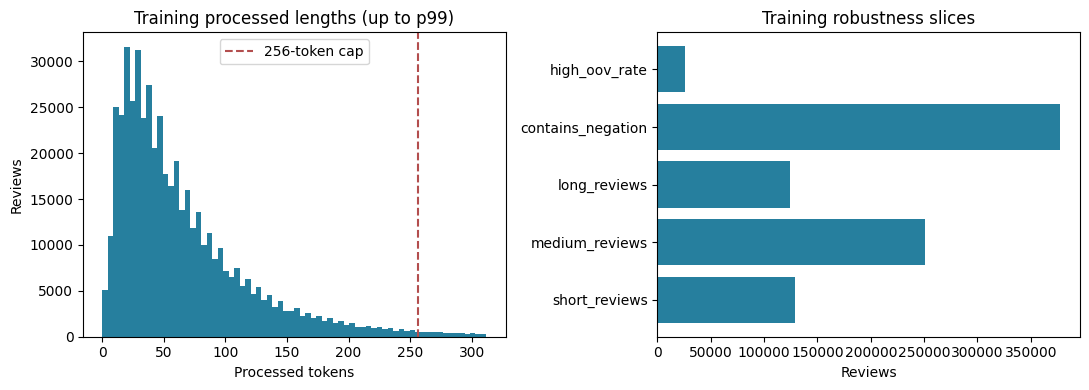

{
  "population": "training membership only",
  "examples": 504000,
  "minimum": 0,
  "maximum": 953,
  "mean": 68.49914682539682,
  "percentiles": {
    "25": 27.0,
    "50": 50.0,
    "75": 89.0,
    "90": 144.0,
    "95": 190.0,
    "99": 312.0
  },
  "sequence_length": 256,
  "truncated_reviews": 9948,
  "truncation_fraction": 0.01973809523809524,
  "empty_processed_reviews": 31,
  "training_slice_counts": {
    "short_reviews": 128920,
    "medium_reviews": 250581,
    "long_reviews": 124499,
    "contains_negation": 377234,
    "high_oov_rate": 25556
  }
}
Frozen slices: {
  "derived_from": "training membership only; effective post-truncation token lengths",
  "quantile_method": "higher",
  "short_upper_inclusive": 27,
  "medium_upper_inclusive": 89,
  "high_oov_threshold": 0.02040816326530612,
  "high_oov_comparator": ">= threshold and > 0",
  "negation_words": [
    "barely",
    "hardly",
    "neither",
    "never",
    "no",
    "nor",
    "not",
    "scarcely",
    "without"

In [9]:
training_lengths = np.load(PROCESSED_ROOT / 'train_lengths.npy', mmap_mode='r', allow_pickle=False)
full_lengths = np.load(PROCESSED_ROOT / 'train_processed_lengths.npy', mmap_mode='r', allow_pickle=False)
training_oov = np.load(PROCESSED_ROOT / 'train_oov_rates.npy', mmap_mode='r', allow_pickle=False)
training_negation = np.load(PROCESSED_ROOT / 'train_contains_negation.npy', mmap_mode='r', allow_pickle=False)
slice_definitions = yelp.derive_slice_definitions(training_lengths, training_oov)
masks = yelp.slice_masks(training_lengths, training_oov, training_negation, slice_definitions)
slice_path = MEMBER_ROOT / 'configs/robustness_slices.json'
if slice_path.exists() and json.loads(slice_path.read_text()) != slice_definitions:
    raise RuntimeError('Frozen slice definitions differ.')
yelp.write_json(slice_path, slice_definitions)
length_summary = {
    'population': 'training membership only', 'examples': len(full_lengths),
    'minimum': int(full_lengths.min()), 'maximum': int(full_lengths.max()),
    'mean': float(full_lengths.mean()),
    'percentiles': {str(q): float(np.percentile(full_lengths, q)) for q in [25, 50, 75, 90, 95, 99]},
    'sequence_length': SEQUENCE_LENGTH,
    'truncated_reviews': int((full_lengths > SEQUENCE_LENGTH).sum()),
    'truncation_fraction': float((full_lengths > SEQUENCE_LENGTH).mean()),
    'empty_processed_reviews': int((full_lengths == 0).sum()),
    'training_slice_counts': {name: int(mask.sum()) for name, mask in masks.items()}}
yelp.write_json(MEMBER_ROOT / 'outputs/metrics/processed_training_analysis.json', length_summary)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
upper = max(SEQUENCE_LENGTH, int(np.percentile(full_lengths, 99)))
axes[0].hist(full_lengths, bins=70, range=(0, upper), color='#267f9e')
axes[0].axvline(SEQUENCE_LENGTH, color='#b34e4e', linestyle='--', label='256-token cap')
axes[0].set(title='Training processed lengths (up to p99)', xlabel='Processed tokens', ylabel='Reviews')
axes[0].legend()
names = list(masks)
axes[1].barh(names, [int(masks[name].sum()) for name in names], color='#267f9e')
axes[1].set(title='Training robustness slices', xlabel='Reviews')
fig.tight_layout()
fig.savefig(MEMBER_ROOT / 'outputs/plots/processed_training_distribution.png', dpi=160)
plt.show()
print(json.dumps(length_summary, indent=2))
print('Frozen slices:', json.dumps(slice_definitions, indent=2))


## 9. Save the required evaluation contract

No scores are produced here. Notebook 05 will implement this contract for each
frozen model. PR-AUC is reported as average precision to match the uploaded team
evaluator; trapezoidal PR area will also be labeled separately to remove ambiguity.
ECE uses confidence in the predicted class and 15 uniform bins over `[0, 1]`.

Bootstrap resamples whole test rows, preserving paired membership across models.
The planned McNemar family is baseline vs experiment 1 and baseline vs
experiment 2, with Holm adjustment over the two tests. Model selection and any
calibration choices use validation only. Architecture and hyperparameter configs
are supplied separately after you choose and explain your designs.

In [10]:
evaluation_protocol = {
    'protocol_id': 'viraat_yelp_evaluation_v1', 'status': 'metric_definitions_frozen_before_training',
    'positive_label': 1, 'classification_threshold': 0.5,
    'confusion_matrix_label_order': [0, 1],
    'precision_recall_f1': {'averages': ['macro', 'micro', 'weighted'],
                            'labels': [0, 1], 'zero_division': 0},
    'required_metrics': ['accuracy', 'precision_macro', 'precision_micro', 'precision_weighted',
        'recall_macro', 'recall_micro', 'recall_weighted', 'f1_macro', 'f1_micro', 'f1_weighted',
        'confusion_matrix', 'roc_auc', 'pr_auc_average_precision', 'mcc', 'brier_score', 'ece_15_bins'],
    'pr_auc_primary': 'sklearn average_precision_score; positive class 1',
    'additional_pr_auc': 'trapezoidal precision-recall curve area, separately named',
    'brier': 'mean((P(positive)-label)**2)',
    'ece': {'bins': 15, 'edges': 'uniform [0,1]',
            'confidence': 'max(P(positive),1-P(positive))',
            'correctness': 'prediction at fixed threshold 0.5 equals label',
            'aggregation': 'sum(bin_fraction * abs(bin_accuracy-bin_mean_confidence))',
            'edge_policy': 'left-inclusive/right-exclusive, last bin includes 1; skip empty bins'},
    'bootstrap': {'method': 'unstratified nonparametric percentile with replacement',
                  'replicates': 2000, 'replicate_size': 38000, 'confidence_level': 0.95,
                  'seed': 2662502, 'quantile_method': 'linear',
                  'shared_row_resamples_across_models': True,
                  'metrics': ['accuracy', 'f1_macro', 'mcc']},
    'mcnemar': {'paired_on': 'identical official test source IDs',
                'family': [['baseline', 'experiment_1'], ['baseline', 'experiment_2']],
                'test': 'chi-square, df=1, continuity correction',
                'statistic': '(abs(b-c)-1)**2/(b+c); if b+c=0, statistic=0 and p=1',
                'adjustment': 'Holm, family size 2', 'alpha': 0.05},
    'slice_config_sha256': yelp.sha256_file(slice_path),
    'slice_metrics': ['macro_f1', 'error_rate', 'count', 'fraction'],
    'resources_per_model': ['total_parameter_count', 'trainable_parameter_count',
        'total_training_wall_seconds', 'training_examples_per_second',
        'peak_cuda_allocated_mib', 'peak_cuda_reserved_mib', 'cpu_model', 'gpu_model'],
    'throughput_definition': 'processed training examples across all completed epochs / summed synchronized training-phase seconds',
    'time_definition': 'training run wall time including validation; data preparation reported separately',
    'manual_review': {'total_unique_errors': 20,
                      'groups': {'confident_false_positive': 5, 'confident_false_negative': 5,
                                 'near_threshold_error': 5, 'slice_specific_failure': 5},
                      'required_human_fields': ['error_type', 'explanation', 'testable_fix'],
                      'annotations': 'written by Viraat after inspecting actual errors'},
    'official_test_policy': 'No test-based model, checkpoint, hyperparameter, threshold or slice selection; '
                            'one frozen final evaluation with saved predictions for later statistics and error review.',
    'reference': 'Uploaded Anshika 05 notebook consulted for metric conventions only',
    'architecture_choices': 'pending student selection; no model implementations in notebook 01'}
eval_path = MEMBER_ROOT / 'configs/evaluation_protocol.json'
if eval_path.exists() and json.loads(eval_path.read_text()) != evaluation_protocol:
    raise RuntimeError('Frozen metric definitions differ; do not replace them after training.')
yelp.write_json(eval_path, evaluation_protocol)
print('PASS: all Task 2 evaluation requirements recorded. No test metrics claimed.')


PASS: all Task 2 evaluation requirements recorded. No test metrics claimed.


## 10. Verify artifacts and back up the completed preprocessing stage

Processed datasets stay under ignored `task2_sentiment/data/`, outside GitHub.
This cell zips the encoded train/validation dataset, verifies the Drive copy,
and saves your configs, helper, plots, manifests and unchanged logs separately.
The original publicly readable raw-data ZIP and link are retained. The new
processed ZIP is a training backup; it is not assumed to inherit that public link.

In [11]:
assert not list(PROCESSED_ROOT.glob('test_*')), 'Test artifacts should not exist at this stage.'
for name in ('train', 'validation'):
    data = np.load(PROCESSED_ROOT / f'{name}_input_ids.npy', mmap_mode='r', allow_pickle=False)
    assert data.shape == (encoding_summaries[name]['rows'], SEQUENCE_LENGTH)
    assert data.dtype == np.int32
    assert int(data.min()) >= 0 and int(data.max()) < len(vocabulary)
data_manifest = {
    'member': MEMBER_NAME, 'run_id': RUN_ID,
    'raw_source_run_id': RAW_RUN_ID,
    'data_protocol_sha256': yelp.sha256_file(data_protocol_path),
    'split_manifest_sha256': yelp.sha256_file(split_path),
    'vocabulary_sha256': yelp.sha256_file(vocabulary_path),
    'preprocessing_helper_sha256': yelp.sha256_file(helper_path),
    'evaluation_protocol_sha256': yelp.sha256_file(eval_path),
    'robustness_slices_sha256': yelp.sha256_file(slice_path),
    'cache_key': CACHE_KEY, 'encoded_splits': encoding_summaries,
    'official_test_preprocessed': False, 'official_test_evaluated': False}
manifest_path = MEMBER_ROOT / 'outputs/metrics/data_artifact_manifest.json'
yelp.write_json(manifest_path, data_manifest)

archive_name = f'viraat_yelp_processed_{RUN_ID}.zip'
drive_archive = DRIVE_RUN_ROOT / archive_name
processed_backup_path = MEMBER_ROOT / 'outputs/metrics/processed_dataset_backup.json'
reuse_backup = False
if processed_backup_path.exists() and drive_archive.exists():
    previous = json.loads(processed_backup_path.read_text())
    reuse_backup = (previous['data_artifact_manifest_sha256'] == yelp.sha256_file(manifest_path)
                    and previous['sha256'] == yelp.sha256_file(drive_archive))
if reuse_backup:
    processed_backup = previous
    print('Reusing the verified processed-data backup.')
else:
    local_archive = WORKSPACE / archive_name
    with zipfile.ZipFile(local_archive, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=1) as archive:
        for path in sorted(PROCESSED_ROOT.iterdir()):
            if path.is_file():
                archive.write(path, Path('processed') / MEMBER_NAME / path.name)
    with zipfile.ZipFile(local_archive) as archive:
        bad = archive.testzip()
        if bad is not None:
            raise RuntimeError('Processed archive failed its CRC check: ' + bad)
    expected_hash = yelp.sha256_file(local_archive)
    temp_copy = drive_archive.with_name(drive_archive.name + '.part')
    shutil.copy2(local_archive, temp_copy)
    if yelp.sha256_file(temp_copy) != expected_hash:
        raise RuntimeError('Drive processed-dataset copy differs from the local ZIP.')
    temp_copy.replace(drive_archive)
    processed_backup = {
        'zip_filename': archive_name, 'sha256': expected_hash,
        'bytes': drive_archive.stat().st_size, 'drive_backup_verified': True,
        'data_artifact_manifest_sha256': yelp.sha256_file(manifest_path),
        'restore_to': 'task2_sentiment/data/; ZIP contains processed/Viraat_Chaudhary/',
        'sharing_status': 'private training backup; public reference remains the original raw dataset ZIP'}
    yelp.write_json(processed_backup_path, processed_backup)

existing_ignore = MEMBER_ROOT / '.gitignore'
entries = existing_ignore.read_text().splitlines() if existing_ignore.exists() else []
for entry in ['data_processed/', 'hf_cache/', '__pycache__/', '.ipynb_checkpoints/', '*.zip']:
    if entry not in entries:
        entries.append(entry)
existing_ignore.write_text('\n'.join(entries) + '\n')
task_ignore = WORKSPACE / 'task2_sentiment/.gitignore'
entries = task_ignore.read_text().splitlines() if task_ignore.exists() else []
for entry in ['data/', '*.zip']:
    if entry not in entries:
        entries.append(entry)
task_ignore.write_text('\n'.join(entries) + '\n')
(MEMBER_ROOT / 'requirements.lock.txt').write_text(
    subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], text=True))

readme_path = MEMBER_ROOT / 'README.md'
original = readme_path.read_text() if readme_path.exists() else '# Task 2 — Viraat Chaudhary\n'
marker = '<!-- VIRAAT_TASK2_PREPROCESSING -->'
if marker not in original:
    additions = ('\n' + marker + '\n## Preprocessing artifacts\n\n'
        'Run `notebooks/01_data_analysis_preprocessing.ipynb` in Colab after mounting Drive.\n\n'
        f'Raw dataset: [Yelp Polarity ZIP folder]({DATASET_DRIVE_URL}). '
        f'ZIP: `{backup_record["zip_filename"]}`. '
        'Read access and download were confirmed by the user in a private browser window.\n\n'
        'Official training rows are split into 504,000 training and 56,000 validation '
        'reviews with stratified seed 2662501. Training-only vocabulary limit: 50,000 '
        'including PAD/UNK/EMPTY; minimum frequency: 2; sequence length: 256. '
        'Literal escaped newlines, carriage returns and tabs are normalized before tokenization. '
        'Embeddings will be randomly initialized and learned from scratch.\n\n'
        'The official test set is reserved for notebook 05 after all three models '
        'are frozen. Actual preprocessing statistics and duplicate audit are in '
        '`outputs/metrics/processed_training_analysis.json` and '
        '`outputs/metrics/duplicate_training_audit.json`. '
        'Student findings and model results are still pending.\n\n'
        'Assistant assistance: data handling and checks. Team reference notebooks '
        'were consulted for split/metric conventions; teammate model code was not copied. '
        'Core architecture choices and manual analysis are written by the student.\n')
    readme_path.write_text(original.rstrip() + '\n' + additions)

completion = {
    'status': 'PASS', 'stage': 'Task 2 preprocessing only', 'run_id': RUN_ID,
    'raw_source_run_id': RAW_RUN_ID, 'preprocessing_revision': 2,
    'training_examples': 504000, 'validation_examples': 56000,
    'vocabulary_size': len(vocabulary), 'sequence_length': SEQUENCE_LENGTH,
    'train_validation_index_overlap': 0, 'processed_backup_verified': True,
    'official_test_preprocessed': False, 'official_test_evaluated': False,
    'models_selected_or_trained': False,
    'preprocessing_wall_seconds_this_execution': time.perf_counter() - STARTED,
    'member': MEMBER_NAME, 'teammate_files_modified': False}
yelp.write_json(MEMBER_ROOT / 'outputs/metrics/preprocessing_completion.json', completion)
log_event('preprocessing_completed', completion=completion, processed_backup=processed_backup)
shutil.copytree(MEMBER_ROOT, DRIVE_RUN_ROOT / 'preprocessing_evidence', dirs_exist_ok=True)
print('PASS — Task 2 data analysis and preprocessing completed; artifacts backed up.')
print(json.dumps(completion, indent=2))
print('Next: save the executed notebook as Viraat_01_data_analysis_preprocessing.ipynb.')
print('Then supply your baseline and two experimental designs with your reasons before notebook 02.')


PASS — Task 2 data analysis and preprocessing completed; artifacts backed up.
{
  "status": "PASS",
  "stage": "Task 2 preprocessing only",
  "run_id": "20261001T203954337938Z_preprocessing_v2",
  "raw_source_run_id": "20261001T203954337938Z",
  "preprocessing_revision": 2,
  "training_examples": 504000,
  "validation_examples": 56000,
  "vocabulary_size": 50000,
  "sequence_length": 256,
  "train_validation_index_overlap": 0,
  "processed_backup_verified": true,
  "official_test_preprocessed": false,
  "official_test_evaluated": false,
  "models_selected_or_trained": false,
  "preprocessing_wall_seconds_this_execution": 208.67392199300002,
  "member": "Viraat_Chaudhary",
  "teammate_files_modified": false
}
Next: save the executed notebook as Viraat_01_data_analysis_preprocessing.ipynb.
Then supply your baseline and two experimental designs with your reasons before notebook 02.


## Your findings and next stage

After execution, write your own interpretation of class balance, review lengths,
empty-review handling, truncation, OOV behavior and the duplicate audit. Do not
replace actual results with expected or teammate values.

Save this executed notebook with its outputs. The notebook itself is not
automatically copied into the Drive evidence folder: use Colab **File → Download
→ Download .ipynb**, or save a copy in Drive. Training arrays are already backed up.

Before notebook 02, choose and justify your three distinct model designs and
embedding dimensions. Anshika's lineup is masked-mean pooling + linear,
multi-kernel TextCNN, and BiGRU with attention. Your choices must be distinct from
each other and from her architecture/hyperparameter combinations. No pretrained
embeddings or pretrained language models are permitted. Better test results can
only be established by the actual frozen evaluation.

Remaining notebooks stay separate:

| Notebook | Purpose |
|---|---|
| 02_train_baseline.ipynb | Your baseline training and validation-only selection |
| 03_train_experiment_1.ipynb | Your first experimental model |
| 04_train_experiment_2.ipynb | Your second experimental model |
| 05_evaluate_compare_models.ipynb | All metrics, uncertainty, paired tests, slices and comparisons |
| 06_manual_error_analysis.ipynb | 20 actual errors; your own types, explanations and testable fixes |
| 07_evaluator_demo.ipynb | Saved-model evaluator smoke demonstration |

This stage does not edit the shared repository README. When results are ready,
preserve Anshika's existing findings and append your own below them, with the
accessible dataset link and reproducible smoke command.

Sources: course brief Task 2 and general requirements; the supplied TA Yelp/Drive
correction; your existing Cell 6; uploaded teammate notebooks 01 and 05 for shared
split/metric conventions only; [Yelp dataset card](https://huggingface.co/datasets/fancyzhx/yelp_polarity),
[NLTK Porter stemmer](https://www.nltk.org/api/nltk.stem.porter.html),
[NLTK corpora](https://www.nltk.org/howto/corpus.html),
[scikit-learn split API](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html),
[NumPy memory-mapped arrays](https://numpy.org/doc/stable/reference/generated/numpy.lib.format.open_memmap.html).

## Export the corrected evidence

This cell downloads a small ZIP of your corrected member artifacts. It excludes
generated Python bytecode. The dataset ZIPs remain separately backed up in Drive.
After this cell, download the executed notebook through **File → Download → Download .ipynb**.
Keep the filename `Viraat_01_data_analysis_preprocessing.ipynb` and upload it with
`Viraat_Task2_Preprocessing_Evidence.zip` for review.

In [12]:
from google.colab import files
evidence_zip = Path('/content/Viraat_Task2_Preprocessing_Evidence.zip')
with zipfile.ZipFile(evidence_zip, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(MEMBER_ROOT.rglob('*')):
        if path.is_file() and '__pycache__' not in path.parts and path.suffix != '.pyc':
            archive.write(path, Path(MEMBER_NAME) / path.relative_to(MEMBER_ROOT))
print('Corrected evidence:', evidence_zip.name)
files.download(str(evidence_zip))


Corrected evidence: Viraat_Task2_Preprocessing_Evidence.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>